# ***Task 3:- Build a Baseline Model***

#### ***Import Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### ***Read the Dataset***

In [2]:
df = pd.read_csv('smartphones_prepared.csv')

In [3]:
df.shape

(2256, 14)

In [4]:
df.head()

,model_name,price,expert_rating,user_rating,processor,rear_cameras,front_cameras,display,ram_internal_memory,battery,operating_system,additional_features,review,review_link
0,vivo V40,"34,999",7.8,4.5 ★\n1.3L Ratings,Snapdragon 7 Gen 3 Octa core,50+50 MP Rear Camera,50 MP Front Camera,6.78″ (17.22 cm) 120Hz AMOLED Display,8 GB RAM | 128 GB Storage,5500 mAh | 80W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...
1,OPPO K12x,"12,999",7.8,4.5 ★\n1.3L Ratings,MediaTek Dimensity 6300 Octa core,32+2 MP Rear Camera,8 MP Front Camera,6.67″ (16.94 cm) 120Hz LCD Display,6 GB RAM | 128 GB Storage,5100 mAh | 45W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...
2,vivo V40 Pro,"49,999",8.2,4.5 ★\n1.3L Ratings,MediaTek Dimensity 9200 Plus Octa core,50+50+50 MP Rear Camera,50 MP Front Camera,6.78″ (17.22 cm) 120Hz AMOLED Display,8 GB RAM | 256 GB Storage,5500 mAh | 80W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,"The Vivo V40 Pro shines with its cameras, perf...",https://www.mysmartprice.com/gear/mobiles/mobi...
3,Motorola Edge 50 Fusion,"24,879",8.1,4.5 ★\n16.9K Ratings,Snapdragon 7s Gen 2 Octa core,50+13 MP Rear Camera,32 MP Front Camera,6.67″ (16.94 cm) 144Hz P-OLED Display,8 GB RAM | 128 GB Storage,5000 mAh | 68W Fast Charging,Android v14 OS,5G | NFC | Fingerprint Sensor,Moto Edge 50 Fusion has a premium design and s...,https://www.mysmartprice.com/gear/mobiles/mobi...
4,Samsung Galaxy M35 5G,"19,999",7.8,4.3 ★\n383 Ratings,Samsung Exynos 1380 Octa core,50+8+2 MP Rear Camera,13 MP Front Camera,6.6″ (16.76 cm) 120Hz Super AMOLED Display,6 GB RAM | 128 GB Storage,6000 mAh | 25W Fast Charging,Android v14 OS,5G | NFC | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...


#### ***Check the infomation of dataset***

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_name           2256 non-null   object 
 1   price                2256 non-null   object 
 2   expert_rating        2256 non-null   float64
 3   user_rating          2256 non-null   object 
 4   processor            2256 non-null   object 
 5   rear_cameras         2256 non-null   object 
 6   front_cameras        2256 non-null   object 
 7   display              2256 non-null   object 
 8   ram_internal_memory  2256 non-null   object 
 9   battery              2256 non-null   object 
 10  operating_system     2256 non-null   object 
 11  additional_features  2256 non-null   object 
 12  review               2256 non-null   object 
 13  review_link          2256 non-null   object 
dtypes: float64(1), object(13)
memory usage: 246.9+ KB


#### ***Check Missing Values***

In [6]:
df.isnull().sum()

model_name             0
price                  0
expert_rating          0
user_rating            0
processor              0
rear_cameras           0
front_cameras          0
display                0
ram_internal_memory    0
battery                0
operating_system       0
additional_features    0
review                 0
review_link            0
dtype: int64

#### ***Check Duplicat Values***

In [7]:
df.duplicated().sum()

np.int64(0)

#### ***Convert Price into Numeric Format***

In [8]:
df['price'].head(10)

0    34,999
1    12,999
2    49,999
3    24,879
4    19,999
5    24,998
6    18,880
7    29,998
8    29,495
9    27,999
Name: price, dtype: object

In [9]:
df['price_numeric'] = (
    df['price'].astype(str)
    .str.replace(',', '', regex = False)
    .str.replace("₹", "", regex = False)
    .str.extract(r"(\d+(?:\.\d+)?)", expand = False)
)

df['price_numeric'] = pd.to_numeric(df['price_numeric'], errors = 'coerce')
df[['price', 'price_numeric']].head()

,price,price_numeric
0,"34,999",34999
1,"12,999",12999
2,"49,999",49999
3,"24,879",24879
4,"19,999",19999


In [10]:
print("Missing price values:", df["price_numeric"].isnull().sum())

Missing price values: 0


### ***Prepare Features***

### ***RAM***

In [11]:
ram_text = df['ram_internal_memory'].astype(str)

ram_gb = ram_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*GB\s*RAM",
    expand = False
)

ram_mb = ram_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*MB\s*RAM",
    expand = False
)

ram_gb = pd.to_numeric(ram_gb, errors = 'coerce')
ram_mb = pd.to_numeric(ram_mb, errors = 'coerce')

df['ram_gb'] = ram_gb
df.loc[df['ram_gb'].isna(), 'ram_gb'] = ram_mb[df['ram_gb'].isna()] / 1024

#### ***Storage***

In [12]:
storage_text = df['ram_internal_memory'].astype(str)

storage_gb = storage_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*GB\s*Storage",
    expand = False
)

storage_tb = storage_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*TB\s*Storage",
    expand = False
)

storage_mb = storage_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*MB\s*Storage",
    expand = False
)

storage_gb = pd.to_numeric(storage_gb, errors = 'coerce')
storage_tb = pd.to_numeric(storage_tb, errors = 'coerce')
storage_mb = pd.to_numeric(storage_mb, errors = 'coerce')

df['storage_gb'] = storage_gb

df.loc[df['storage_gb'].isna(), 'storage_gb'] = storage_tb[df['storage_gb'].isna()] * 1024
df.loc[df['storage_gb'].isna(), 'storage_gb'] = storage_mb[df['storage_gb'].isna()] / 1024

#### ***Convert Battery***

In [13]:
df['battery_mAh'] = (df['battery'].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df['battery_mAh'] = pd.to_numeric(df['battery_mAh'], errors = 'coerce')

In [14]:
df[["battery", "battery_mAh"]].head()

,battery,battery_mAh
0,5500 mAh | 80W Fast Charging,5500
1,5100 mAh | 45W Fast Charging,5100
2,5500 mAh | 80W Fast Charging,5500
3,5000 mAh | 68W Fast Charging,5000
4,6000 mAh | 25W Fast Charging,6000


#### ***Convert Camera Features***

In [15]:
df['rear_camera_mp'] = (df['rear_cameras'].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df['rear_camera_mp'] = pd.to_numeric(df['rear_camera_mp'], errors = 'coerce')

#### ***Front Camera***

In [16]:
df['front_camera_mp'] = (df['front_cameras'].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df['front_camera_mp'] = pd.to_numeric(df['front_camera_mp'], errors = 'coerce')

#### ***Convert Display Size***

In [17]:
df["display_size"] = (
    df["display"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
)

df["display_size"] = pd.to_numeric(df["display_size"], errors = "coerce")

#### ***Convert User Rating***

In [18]:
df["user_rating_numeric"] = (
    df["user_rating"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
)

df["user_rating_numeric"] = pd.to_numeric(df["user_rating_numeric"], errors = "coerce")

#### ***Check Prepared Features***

In [19]:
features = [
    "expert_rating",
    "user_rating_numeric",
    "ram_gb",
    "storage_gb",
    "battery_mAh",
    "rear_camera_mp",
    "front_camera_mp",
    "display_size"
]

df[features + ["price_numeric"]].head()

,expert_rating,user_rating_numeric,ram_gb,storage_gb,battery_mAh,rear_camera_mp,front_camera_mp,display_size,price_numeric
0,7.8,4.5,8.0,128.0,5500,50.0,50.0,6.78,34999
1,7.8,4.5,6.0,128.0,5100,32.0,8.0,6.67,12999
2,8.2,4.5,8.0,256.0,5500,50.0,50.0,6.78,49999
3,8.1,4.5,8.0,128.0,5000,50.0,32.0,6.67,24879
4,7.8,4.3,6.0,128.0,6000,50.0,13.0,6.60,19999


In [20]:
print(df[features + ["price_numeric"]].isnull().sum())

expert_rating          0
user_rating_numeric    0
ram_gb                 6
storage_gb             0
battery_mAh            0
rear_camera_mp         0
front_camera_mp        0
display_size           1
price_numeric          0
dtype: int64


#### ***Handle Missing Values***

- Some extracted numerical features may have missing values because some original text values don't contain the required information.

- For the baseline model, we can fill numerical missing values with the median.

In [21]:
for column in features:
    df[column] = df[column].fillna(df[column].median())

df["price_numeric"] = df["price_numeric"].fillna(df["price_numeric"].median())

print("Missing values after handling:")
print(df[features + ["price_numeric"]].isnull().sum())

Missing values after handling:
expert_rating          0
user_rating_numeric    0
ram_gb                 0
storage_gb             0
battery_mAh            0
rear_camera_mp         0
front_camera_mp        0
display_size           0
price_numeric          0
dtype: int64


#### ***Define features and target***

In [22]:
X = df[features]
y = df["price_numeric"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2256, 8)
Target shape: (2256,)


#### ***Split Dataset***

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (1804, 8)
Testing data: (452, 8)


#### ***Build Baseline Model***

In [24]:
model = LinearRegression()
model.fit(x_train, y_train)
print("Baseline Linear Regression model trained successfully.")

Baseline Linear Regression model trained successfully.


#### ***Make Predictions***

In [25]:
y_pred = model.predict(x_test)
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 9836.14226673 15033.3779608  12949.13162257 31589.88217821
 12215.13483901  6534.76659892 12730.72593293 32039.17742826
 14834.6208123  22472.44738612]


### ***Evaluate the Model***

#### ***MAE***
- Mean Absolute Error tells us the average absolute difference between actual and predicted prices.

In [26]:
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 9734.277526940545


#### ***MSE***
- Mean Squared Error gives more penalty to larger errors.

In [27]:
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

MSE: 214317424.1451786


#### ***RMSE***
- RMSE is the square root of MSE and is expressed in the same unit as the target price.

In [28]:
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 14639.584152057687


#### ***R²-score***
- R² tells us how much variation in smartphone prices is explained by the model.

In [29]:
r2 = r2_score(y_test, y_pred)
print('R² Score:', r2)

R² Score: 0.7032866485101676


#### ***Display All Metrics Together***

In [30]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,9.734278e+03
1,MSE,2.143174e+08
2,RMSE,1.463958e+04
3,R² Score,7.032866e-01


#### ***Actual vs Predicted Prices***

In [31]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,8439,9836.142267
1,6499,15033.377961
2,12490,12949.131623
3,29999,31589.882178
4,13599,12215.134839
5,8990,6534.766599
6,20999,12730.725933
7,15990,32039.177428
8,7999,14834.620812
9,39999,22472.447386


#### ***Visualize Actual vs Predicted***

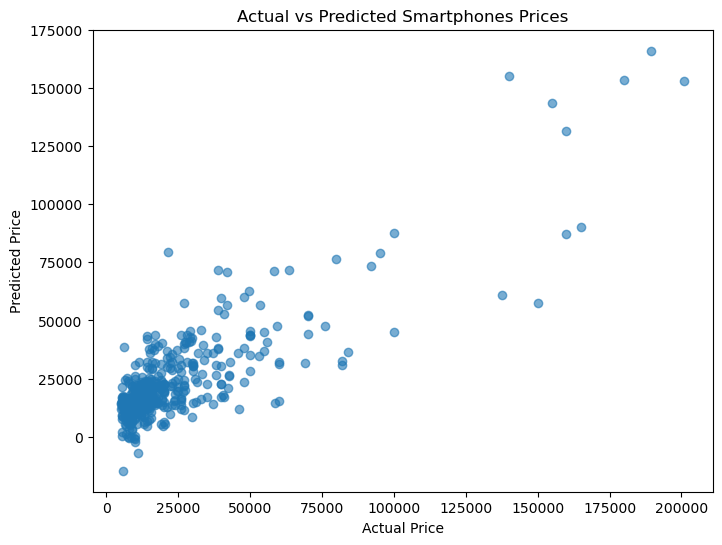

In [32]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred, alpha = 0.6)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Smartphones Prices')
plt.show()

#### ***Add Reference Line***

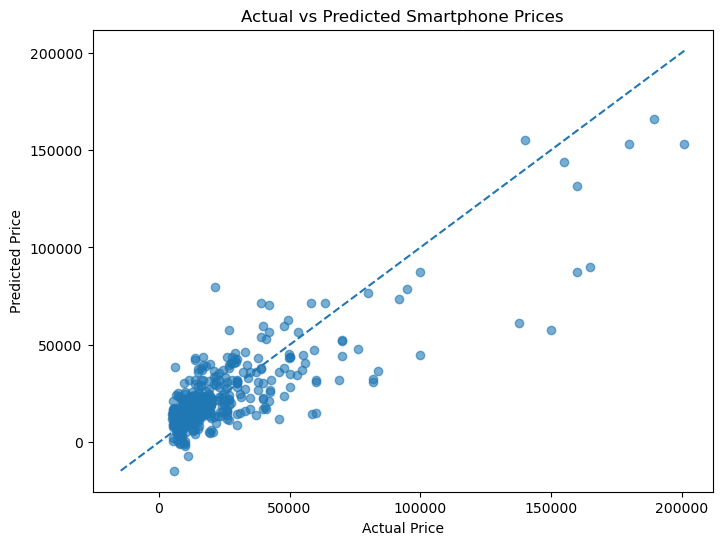

In [33]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Smartphone Prices")
plt.show()

#### ***Check Feature Coefficients***

In [34]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients.sort_values(by = "Coefficient", ascending = False)

,Feature,Coefficient
0,expert_rating,10399.238391
1,user_rating_numeric,1533.709662
2,ram_gb,914.096283
7,display_size,898.229948
3,storage_gb,136.804219
4,battery_mAh,-3.214406
5,rear_camera_mp,-124.523010
6,front_camera_mp,-198.160036


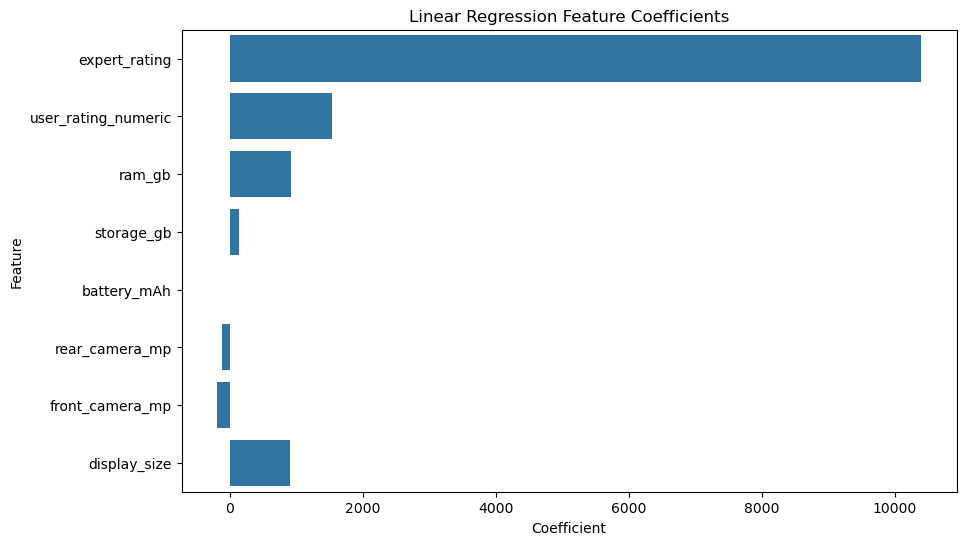

In [35]:
plt.figure(figsize = (10, 6))
sns.barplot(data = coefficients, x = "Coefficient", y = "Feature")
plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

#### ***Check Prediction Errors***

In [36]:
comparison["Error"] = (comparison["Actual Price"] - comparison["Predicted Price"])
comparison.head(10)

,Actual Price,Predicted Price,Error
0,8439,9836.142267,-1397.142267
1,6499,15033.377961,-8534.377961
2,12490,12949.131623,-459.131623
3,29999,31589.882178,-1590.882178
4,13599,12215.134839,1383.865161
5,8990,6534.766599,2455.233401
6,20999,12730.725933,8268.274067
7,15990,32039.177428,-16049.177428
8,7999,14834.620812,-6835.620812
9,39999,22472.447386,17526.552614


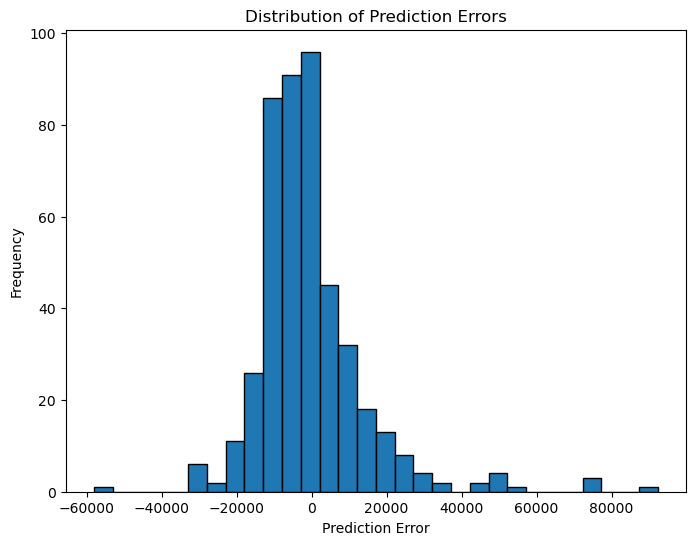

In [37]:
plt.figure(figsize = (8, 6))
plt.hist(comparison["Error"], bins = 30, edgecolor = 'black')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

#### ***Check Model Performance by Price***

In [38]:
comparison["Absolute Error"] = abs(comparison["Error"])
comparison["Actual Price"].describe()

count       452.000000
mean      23146.867257
std       26905.504657
min        5000.000000
25%        9490.000000
50%       14990.000000
75%       25999.000000
max      200999.000000
Name: Actual Price, dtype: float64

In [39]:
comparison.sort_values(by = "Absolute Error", ascending = False).head(10)

,Actual Price,Predicted Price,Error,Absolute Error
331,149999,57719.582428,92279.417572,92279.417572
265,137600,61002.483771,76597.516229,76597.516229
378,164999,90123.108664,74875.891336,74875.891336
293,159999,87280.891530,72718.108470,72718.108470
190,21499,79485.579866,-57986.579866,57986.579866
231,99999,44856.460695,55142.539305,55142.539305
420,81999,30758.505403,51240.494597,51240.494597
125,81900,32397.969663,49502.030337,49502.030337
417,200999,152887.401800,48111.598200,48111.598200
352,83999,36499.000959,47499.999041,47499.999041


#### ***Final Model Summary***

In [40]:
print("===== Baseline Model Summary =====")
print("Model: Linear Regression")
print("Target: Smartphone Price")
print("Training Samples:", len(x_train))
print("Testing Samples:", len(x_test))
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

===== Baseline Model Summary =====
Model: Linear Regression
Target: Smartphone Price
Training Samples: 1804
Testing Samples: 452
MAE: 9734.277526940545
MSE: 214317424.1451786
RMSE: 14639.584152057687
R² Score: 0.7032866485101676
